In [1]:
import glob
import os

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.gait.gait_data.dataset import load_dataset, train_test_split
from src.pose.model_comparison.visualize import plot_jitter_analysis, plot_link_stability
from src.pose.model_comparison.aggregate_results import aggregate_experiment_results
from experiments.gait_detection.config import ExperimentConfig, get_split_config

os.chdir('..')

_cfg = ExperimentConfig()
_split = get_split_config(_cfg.dataset_config)
_all = load_dataset(_cfg.annotations_csv, fps=_cfg.fps, dataset=_cfg.dataset)
_, _, TEST_ATHLETES = train_test_split(
    _all, n_test=_split["n_test"], seed=_split.get("seed", 42)
)

print(f"Test athletes excluded from stability analysis: {TEST_ATHLETES}")

Test athletes excluded from stability analysis: []


# 1. Hyperparameter Tuning

### Fixed Parameters

| Parameter        | Value  |
|:-----------------|:-------|
| `batch`          | 32     |
| `imgsz`          | 640    |
| `workers`        | 2      |
| `warmup_epochs`  | 3.0    |
| `warmup_bias_lr` | 0.0001 |
| `epochs`         | 50     |
| `patience`       | 20     |
| `classes`        | `[0]`  |

---

### Search Space (Hyperparameter Tuning)

| Parameter | Distribution Type | Range / Values    |
| :--- | :--- |:------------------|
| `freeze` | `choice` | `[11, 23]`        |
| `lr0` | `uniform` | `0.00001` to `0.1` |
| `lrf` | `uniform` | `0.01` to `1.0`   |
| `momentum` | `uniform` | `0.6` to `0.98`   |
| `pose` | `uniform` | `10` to `25`      |
| `weight_decay` | `uniform` | `0.0` to `0.001`   |


In total 60 experiments were ran using the Ray Tune package using the search space defined as shown above. Out of them 18 ran for 50 epochs, the rest were stopped early.

In [2]:
hyperparameter_tuning_base_dir = "./runs/train/yolo26l_tune2/"
hyperparameter_tuning_summary_path = f"{hyperparameter_tuning_base_dir}/summary.csv"

hyperparameter_tuning_summary = pd.read_csv(hyperparameter_tuning_summary_path)
top_sets = hyperparameter_tuning_summary.head(4)

In [3]:
all_trial_data = []

for trial_id in top_sets["trial_id"]:
    file_path = f"{hyperparameter_tuning_base_dir}/_tune_{trial_id}/progress.csv"
    df_trial = pd.read_csv(file_path)
    df_trial["trial_id"] = f"Trial_{trial_id}"
    all_trial_data.append(df_trial)

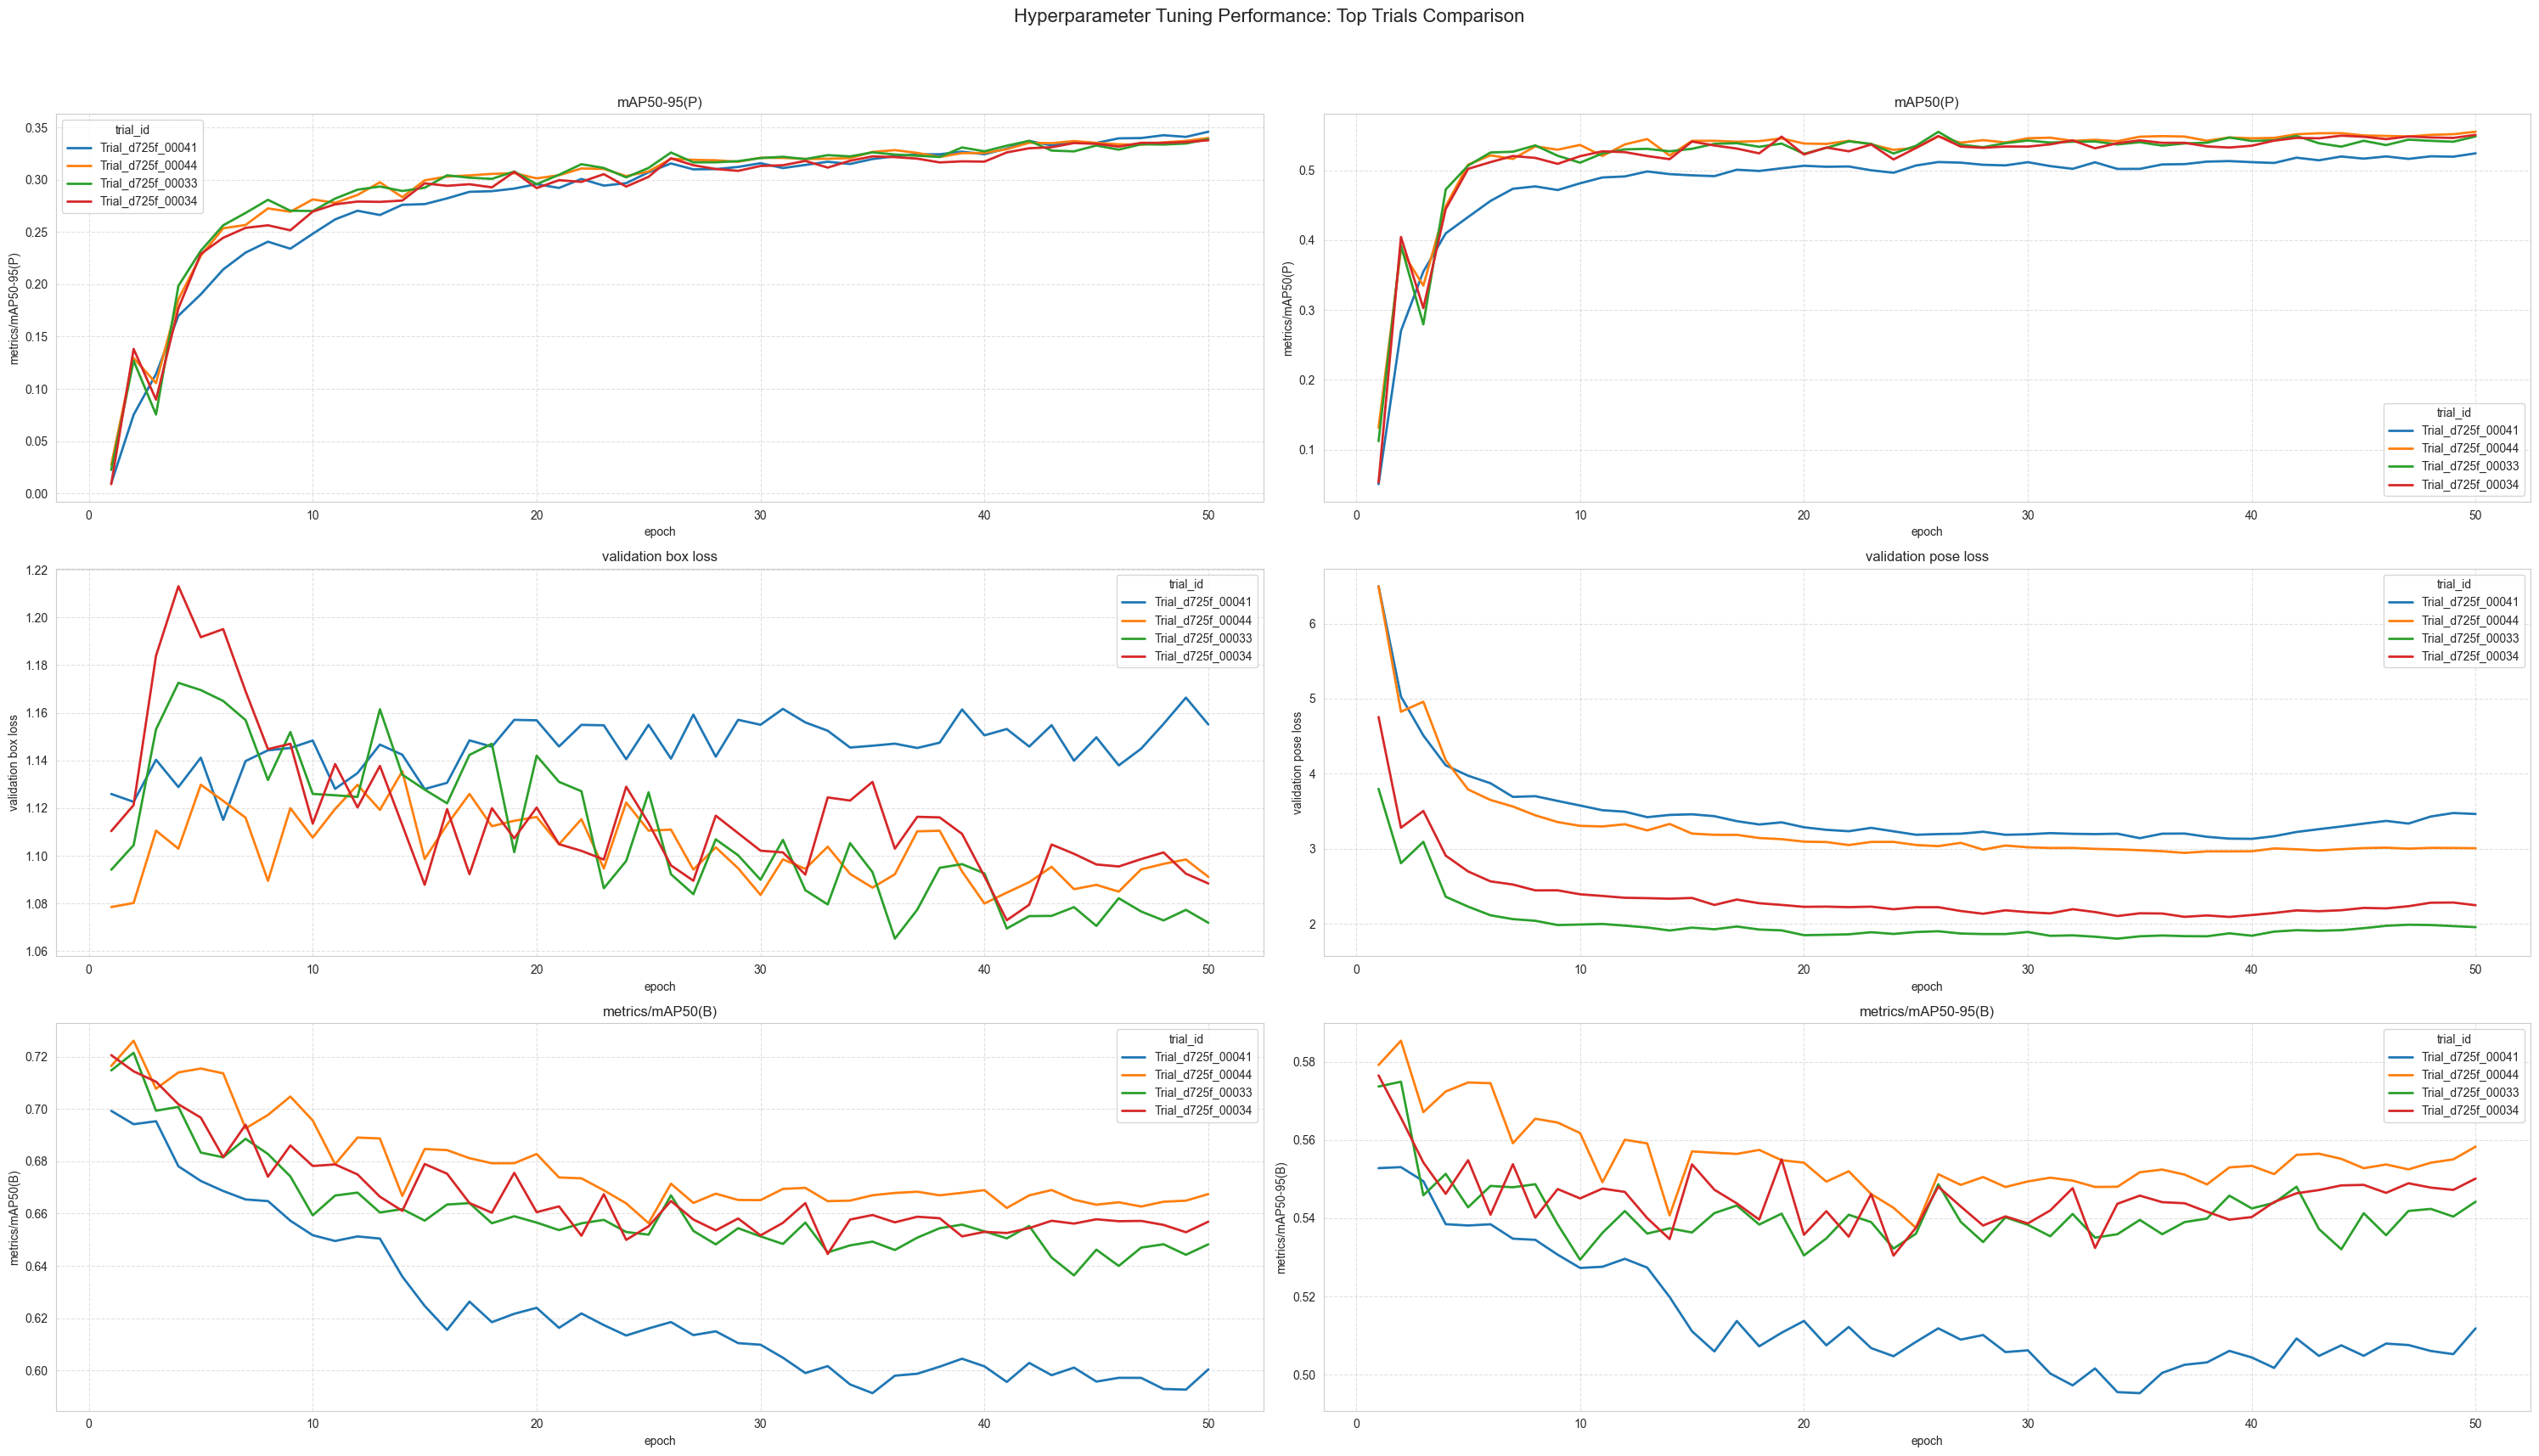

In [4]:
tuning_df = pd.concat(all_trial_data, ignore_index=True)

fig, axes = plt.subplots(3, 2, figsize=(30, 18))
fig.suptitle("Hyperparameter Tuning Performance: Top Trials Comparison", fontsize=16)


sns.lineplot(
    data=tuning_df,
    x="epoch",
    y="metrics/mAP50-95(P)",
    hue="trial_id",
    ax=axes[0, 0],
    linewidth=2,
)
axes[0, 0].set_title("mAP50-95(P)")
axes[0, 0].set_xlabel("epoch")
axes[0, 0].set_ylabel("metrics/mAP50-95(P)")
axes[0, 0].grid(True, linestyle="--", alpha=0.6)

sns.lineplot(
    data=tuning_df,
    x="epoch",
    y="metrics/mAP50(P)",
    hue="trial_id",
    ax=axes[0, 1],
    linewidth=2,
)
axes[0, 1].set_title("mAP50(P)")
axes[0, 1].set_xlabel("epoch")
axes[0, 1].set_ylabel("metrics/mAP50(P)")
axes[0, 1].grid(True, linestyle="--", alpha=0.6)

sns.lineplot(
    data=tuning_df,
    x="epoch",
    y="val/pose_loss",
    hue="trial_id",
    ax=axes[1, 1],
    linewidth=2,
)
axes[1, 1].set_title("validation pose loss")
axes[1, 1].set_xlabel("epoch")
axes[1, 1].set_ylabel("validation pose loss")
axes[1, 1].grid(True, linestyle="--", alpha=0.6)

sns.lineplot(
    data=tuning_df,
    x="epoch",
    y="val/box_loss",
    hue="trial_id",
    ax=axes[1, 0],
    linewidth=2,
)
axes[1, 0].set_title("validation box loss")
axes[1, 0].set_xlabel("epoch")
axes[1, 0].set_ylabel("validation box loss")
axes[1, 0].grid(True, linestyle="--", alpha=0.6)

sns.lineplot(
    data=tuning_df,
    x="epoch",
    y="metrics/mAP50-95(B)",
    hue="trial_id",
    ax=axes[2, 1],
    linewidth=2,
)
axes[2, 1].set_title("metrics/mAP50-95(B)")
axes[2, 1].set_xlabel("epoch")
axes[2, 1].set_ylabel("metrics/mAP50-95(B)")
axes[2, 1].grid(True, linestyle="--", alpha=0.6)

sns.lineplot(
    data=tuning_df,
    x="epoch",
    y="metrics/mAP50(B)",
    hue="trial_id",
    ax=axes[2, 0],
    linewidth=2,
)
axes[2, 0].set_title("metrics/mAP50(B)")
axes[2, 0].set_xlabel("epoch")
axes[2, 0].set_ylabel("metrics/mAP50(B)")
axes[2, 0].grid(True, linestyle="--", alpha=0.6)

plt.tight_layout(rect=(0, 0.03, 1, 0.95))
plt.show()

# 2. Further Training of the Top 4 Models

Top 4 models were chosen for further fine-tuning. Their training parameters are shown below. Each model was trained for 300 epochs with patience set to 100.

In [5]:
parameters = ["freeze", "weight_decay", "lr0", "lrf", "momentum", "pose"]

top_sets[["trial_id", *[f"config/{parameter}" for parameter in parameters]]]

,trial_id,config/freeze,config/weight_decay,config/lr0,config/lrf,config/momentum,config/pose
0,d725f_00041,11,0.000368,0.005502,0.549673,0.847904,16.316130
1,d725f_00044,23,0.000406,0.028867,0.019905,0.802668,19.214190
2,d725f_00033,23,0.000159,0.041379,0.124087,0.859672,11.379308
3,d725f_00034,23,0.000494,0.065985,0.191188,0.613493,13.318544


In [6]:
results = {
    "00033": pd.read_csv(
        "./data/models/yolo/tuned/yolo26l_full_d725f_000332/results.csv"
    ),
    "00034": pd.read_csv(
        "./data/models/yolo/tuned/yolo26l_full_d725f_000342/results.csv"
    ),
    "00041": pd.read_csv(
        "./data/models/yolo/tuned/yolo26l_tune_d725f_000412/results.csv"
    ),
    "00044": pd.read_csv(
        "./data/models/yolo/tuned/yolo26l_tune_d725f_000442/results.csv"
    ),
}

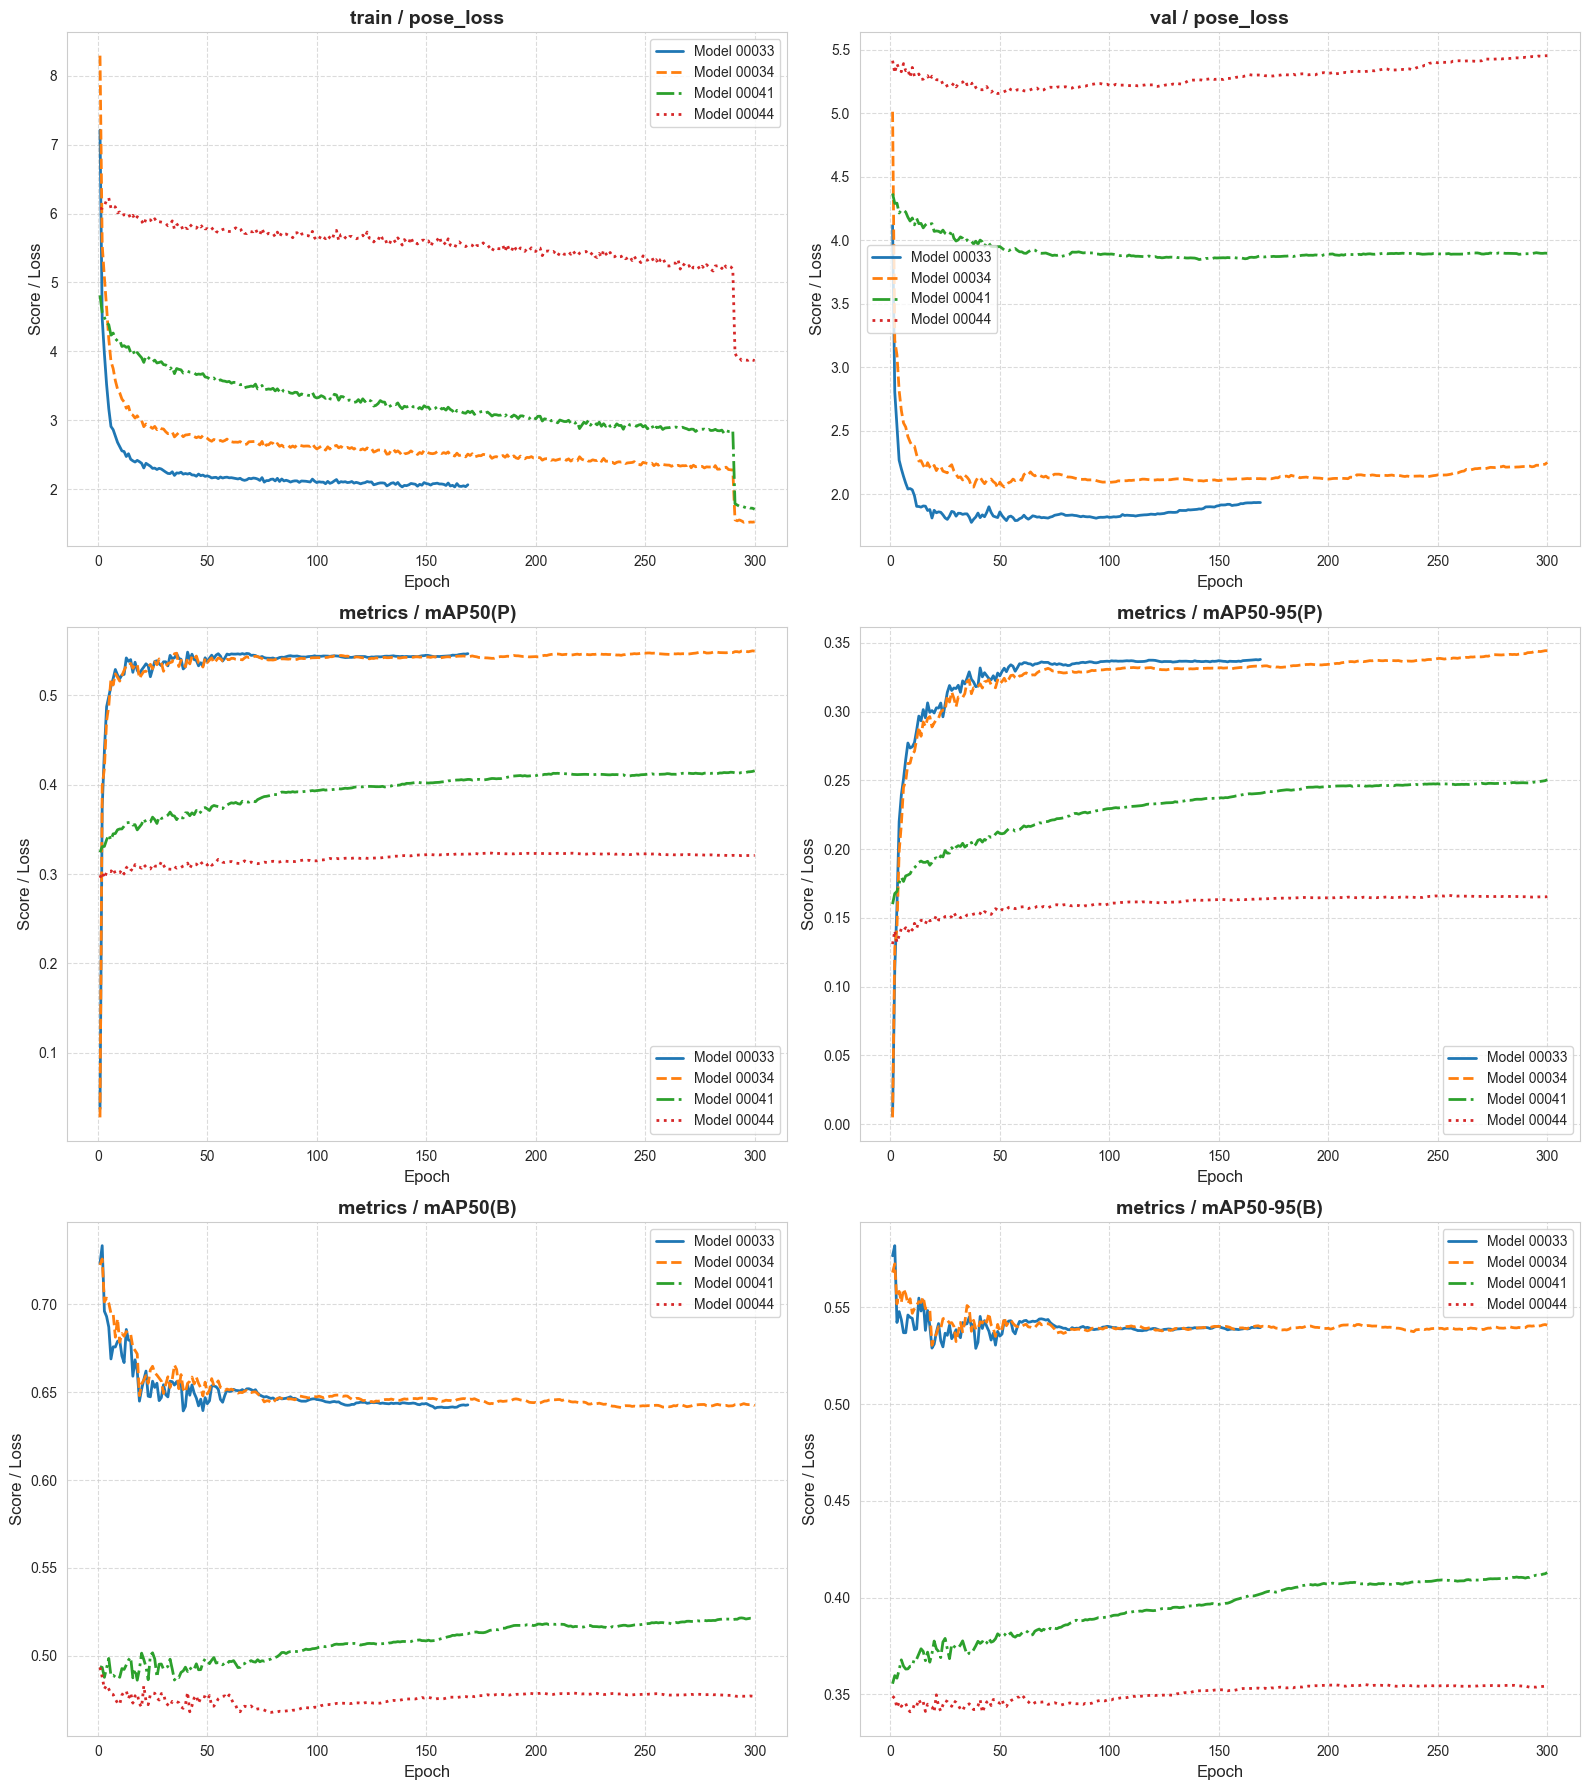

In [7]:
import matplotlib.pyplot as plt

metrics_to_plot = [
    "train/pose_loss",
    "val/pose_loss",
    "metrics/mAP50(P)",
    "metrics/mAP50-95(P)",
    "metrics/mAP50(B)",
    "metrics/mAP50-95(B)",
]

# Define a list of line styles to cycle through
line_styles = ["-", "--", "-.", ":", (0, (3, 5, 1, 5)), (0, (3, 1, 1, 1))]

# 1. First, create the 3x2 grid as originally requested
fig, axes = plt.subplots(3, 2, figsize=(16, 18))
axes_flat = axes.flatten()

for i, metric in enumerate(metrics_to_plot):
    ax = axes_flat[i]

    # Reset line style cycle for each subplot so Model A is always 'solid', etc.
    for j, (model_id, df) in enumerate(results.items()):
        df.columns = df.columns.str.strip()
        x_axis = df["epoch"] if "epoch" in df.columns else df.index

        # Apply unique line style based on index
        style = line_styles[j % len(line_styles)]
        ax.plot(
            x_axis, df[metric], label=f"Model {model_id}", linewidth=2, linestyle=style
        )

    ax.set_title(metric.replace("/", " / "), fontsize=14, fontweight="bold")
    ax.set_xlabel("Epoch", fontsize=12)
    ax.set_ylabel("Score / Loss", fontsize=12)
    ax.legend(loc="best")
    ax.grid(True, linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()

for metric in metrics_to_plot:
    plt.figure(figsize=(10, 6))

    for j, (model_id, df) in enumerate(results.items()):
        df.columns = df.columns.str.strip()
        x_axis = df["epoch"] if "epoch" in df.columns else df.index
        style = line_styles[j % len(line_styles)]

        plt.plot(
            x_axis, df[metric], label=f"Model {model_id}", linewidth=2, linestyle=style
        )

    clean_name = metric.replace("/", "_").replace("(", "").replace(")", "")
    plt.xlabel("Epoch")
    plt.ylabel("Value")
    plt.legend(loc="best")
    plt.grid(True, linestyle="--", alpha=0.7)

    plt.savefig(f"./data/output/plots/learning/{clean_name}.png", dpi=300)
    plt.close()

# 3. Model Stability Comparison

This analysis is restricted to the **annotated visibility window** (frames where legs and torso are fully visible, as marked in the annotations CSV).

* **Jitter**
  Jitter quantifies unnatural, high-acceleration movements for each detected keypoint. It is evaluated using two primary metrics:
  * **Outlier Percentage:** Identifies extreme frame-to-frame jumps. Outliers are statistically defined using the Interquartile Range (IQR) method as any value exceeding $Q_3 + 1.5 \times \text{IQR}$.
  * **Magnitude:** Represents the severity of the jitter, defined as the value at the 95th percentile ($q_{0.95}$) of acceleration.

* **Link Coefficient of Variation (CV)**
  This metric evaluates the consistency of the skeletal structure over time. For every frame, the pixel distance (length) of each relevant link between two connected keypoints is measured. The stability of this link length across the sequence is then calculated using the Coefficient of Variation:

  $$CV = \frac{\sigma}{\mu}$$

  *(where $\sigma$ is the standard deviation of the link length and $\mu$ is the mean link length).*

* **Number of Gaps**
  This tracks missing spatial data. It is defined as the total count of frames within the analyzed window where the model failed to detect either the entire person or specific individual keypoints.

In [8]:
OPTOJUMP_FPS = 120.0

_MODEL_DIR = {
    "00033": "000332",
    "00034": "000342",
    "00041": "000412",
    "00044": "000442",
}


def _athlete_from_path(json_path: str) -> str:
    stem = os.path.splitext(os.path.basename(json_path))[0]
    return "_".join(stem.split("_")[:-1])


def get_paths_for_model(model_id):
    if model_id == "mediapipe":
        base = "./data/output/pose/mediapipe/mediapipe_detector/optojump"
    else:
        base = f"./data/output/pose/tuned_yolo/{_MODEL_DIR[model_id]}/optojump"

    paths = {
        json_path: OPTOJUMP_FPS
        for json_path in sorted(glob.glob(f"{base}/**/*.json", recursive=True))
        if _athlete_from_path(json_path) not in TEST_ATHLETES
    }
    assert paths, f"No pose JSON files found for {model_id!r} under {base}"
    return paths

In [9]:
# ── Annotated visibility frame ranges ───────────────────────────────────────
# Each video was re-annotated so that only frames where legs and torso are
# fully visible are included.  Load those ranges and restrict the stability
# analysis to annotated frames only.
#
# The optojump videos were trimmed before pose extraction: each video starts
# at max(0, first_ann - N_TRIM_PADDING) of the original recording.
# Annotation frame numbers are in original-video coordinates, so they must
# be converted to trimmed-video indices before slicing pose_data.

_ANN_CSV        = "data/output/annotations/optojump/visibility_annotations.csv"
_OPT_VIDEO_BASE = "data/input/optojump"
_N_TRIM_PADDING = 50  # must match the value used when trimming the videos


def _video_stem(video_path: str) -> str:
    """Extract 'study_N/name_M' key from a video_path annotation entry."""
    base = os.path.splitext(video_path)[0]
    return os.path.relpath(base, _OPT_VIDEO_BASE)


def _json_stem(json_path: str) -> str | None:
    """Extract 'study_N/name_M' key from a pose-JSON path."""
    base = os.path.splitext(os.path.normpath(json_path))[0]
    parts = base.replace("\\", "/").split("/")
    try:
        idx = next(i for i, p in enumerate(parts) if p == "optojump")
        return "/".join(parts[idx + 1:])
    except StopIteration:
        return None


# stem → (first_ann, last_ann) in original-video frame coordinates
_ann_df = pd.read_csv(_ANN_CSV)
_stem_to_ann: dict[str, tuple[int, int]] = {}
for _vp, _grp in _ann_df.groupby("video_path"):
    _stem_to_ann[_video_stem(_vp)] = (
        int(_grp["frame_number"].min()),
        int(_grp["frame_number"].max()),
    )

print(f"Loaded annotated frame ranges for {len(_stem_to_ann)} videos from '{_ANN_CSV}'")


def build_frame_ranges(paths_dict: dict) -> dict[str, tuple[int, int]]:
    """Map each pose-JSON path to its annotation window as trimmed-video indices.

    Converts original-video frame numbers from the annotation CSV to 0-based
    indices into pose_data (which was extracted from the trimmed video starting
    at max(0, first_ann - _N_TRIM_PADDING)).
    """
    ranges: dict[str, tuple[int, int]] = {}
    missing = []
    for path in paths_dict:
        stem = _json_stem(path)
        if stem and stem in _stem_to_ann:
            first_ann, last_ann = _stem_to_ann[stem]
            trim_start = max(0, first_ann - _N_TRIM_PADDING)
            # Convert to trimmed-video indices
            first_idx = first_ann - trim_start
            last_idx  = last_ann  - trim_start
            ranges[path] = (first_idx, last_idx)
        else:
            missing.append(path)
    if missing:
        print(f"  ⚠ No annotation range found for {len(missing)} path(s):",
              missing[:3], "..." if len(missing) > 3 else "")
    return ranges


Loaded annotated frame ranges for 179 videos from 'data/output/annotations/optojump/visibility_annotations.csv'


In [10]:
YOLO_LINKS = {
    # Torso
    "Torso_L": ("left_shoulder", "left_hip"),
    "Torso_R": ("right_shoulder", "right_hip"),
    # Legs
    "Thigh_L": ("left_hip", "left_knee"),
    "Thigh_R": ("right_hip", "right_knee"),
    "Shin_L": ("left_knee", "left_ankle"),
    "Shin_R": ("right_knee", "right_ankle"),
    # Feet
    "Foot_L": ("left_heel", "left_big_toe"),
    "Foot_R": ("right_heel", "right_big_toe"),
}

MEDIAPIPE_LINKS = {
    "Torso_L": ("left_shoulder", "left_hip"),
    "Torso_R": ("right_shoulder", "right_hip"),
    "Thigh_L": ("left_hip", "left_knee"),
    "Thigh_R": ("right_hip", "right_knee"),
    "Shin_L": ("left_knee", "left_ankle"),
    "Shin_R": ("right_knee", "right_ankle"),
    "Foot_L": ("left_heel", "left_foot_index"),
    "Foot_R": ("right_heel", "right_foot_index"),
}

# Keypoints included in jitter and gap analysis.
# Restricted to shoulders, hips, and legs — excludes arms, face, hands.
KEYPOINTS_OF_INTEREST = [
    "left_shoulder",  "right_shoulder",
    "left_hip",       "right_hip",
    "left_knee",      "right_knee",
    "left_ankle",     "right_ankle",
    "left_heel",      "right_heel",
    "left_big_toe",   "right_big_toe",
]

MEDIAPIPE_KEYPOINTS_OF_INTEREST = [
    "left_shoulder",    "right_shoulder",
    "left_hip",         "right_hip",
    "left_knee",        "right_knee",
    "left_ankle",       "right_ankle",
    "left_heel",        "right_heel",
    "left_foot_index",  "right_foot_index",
]

In [11]:
model_ids = ["00033", "00034", "00041", "00044"]
metrics_for_model = {}

for model_id in model_ids:
    paths = get_paths_for_model(model_id)
    frame_ranges = build_frame_ranges(paths)
    links, jitter, gaps = aggregate_experiment_results(
        paths, model_id, YOLO_LINKS,
        frame_ranges=frame_ranges,
        keypoints_filter=KEYPOINTS_OF_INTEREST,
    )
    metrics_for_model[model_id] = {
        "links": links,
        "jitter": jitter,
        "gaps": gaps,
    }

mp_paths = get_paths_for_model("mediapipe")
mp_frame_ranges = build_frame_ranges(mp_paths)
links, jitter, gaps = aggregate_experiment_results(
    mp_paths, "mediapipe", MEDIAPIPE_LINKS,
    frame_ranges=mp_frame_ranges,
    keypoints_filter=MEDIAPIPE_KEYPOINTS_OF_INTEREST,
)
model_ids.append("mediapipe")
metrics_for_model["mediapipe"] = {
    "links": links,
    "jitter": jitter,
    "gaps": gaps,
}

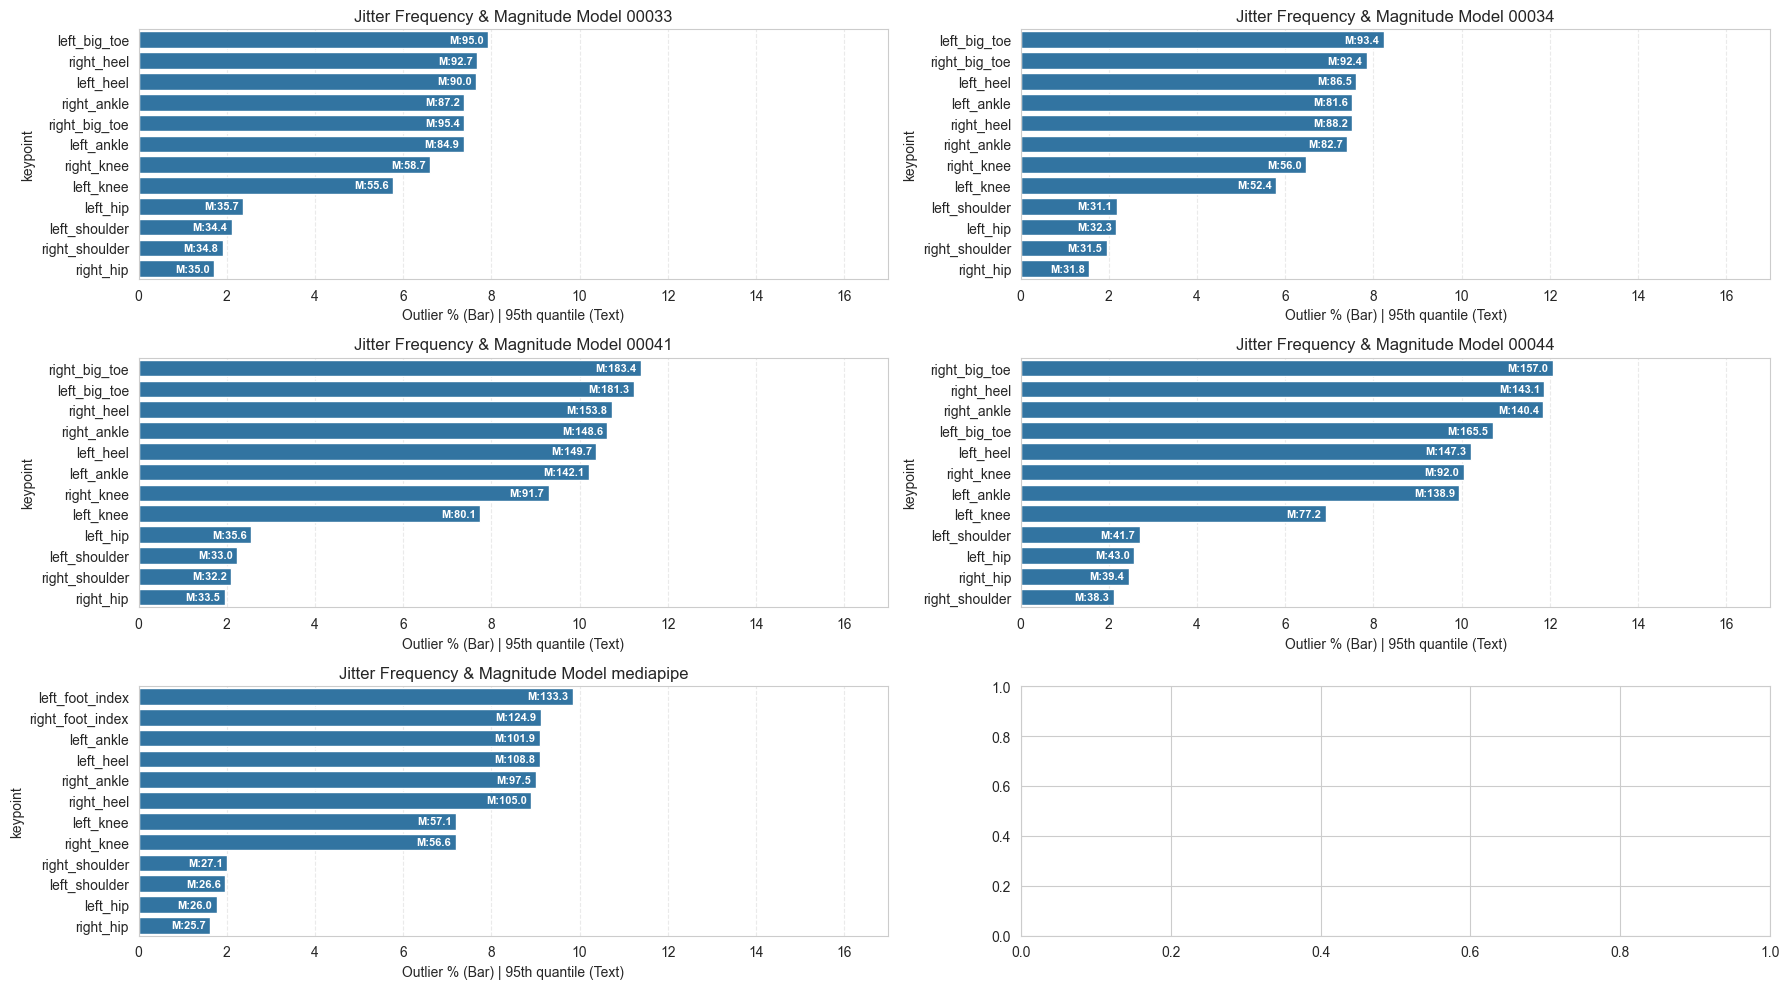

In [12]:
import math

fig, axes = plt.subplots(math.ceil(len(model_ids) / 2), 2, figsize=(18, 10))

axes_flat = axes.flatten()

for i, model_id in enumerate(model_ids):
    jitter = metrics_for_model[model_id]["jitter"]
    plot_jitter_analysis(jitter, axes_flat[i], model_name=f"Model {model_id}")

plt.tight_layout()
plt.show()

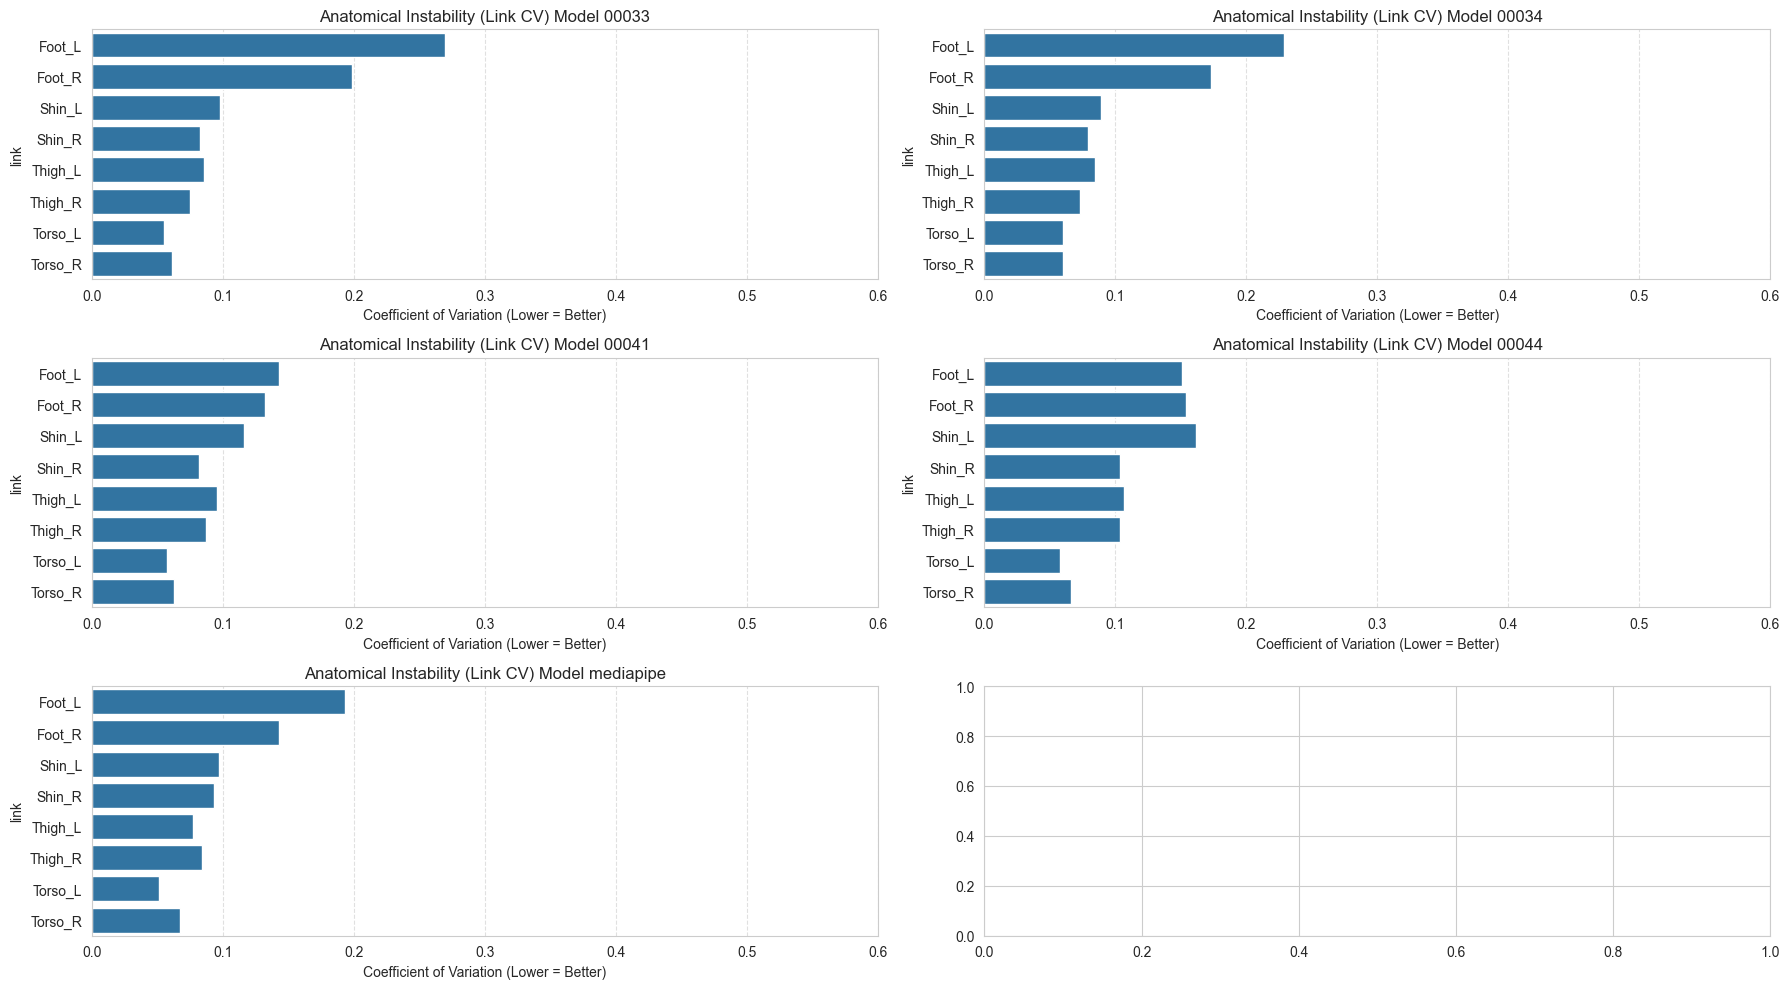

In [13]:
fig, axes = plt.subplots(math.ceil(len(model_ids) / 2), 2, figsize=(18, 10))

axes_flat = axes.flatten()

for i, model_id in enumerate(model_ids):
    links = metrics_for_model[model_id]["links"]
    plot_link_stability(links, axes_flat[i], model_name=f"Model {model_id}")

plt.tight_layout()
plt.show()

In [17]:
mean_gaps_data = {}

for model_id, metrics in metrics_for_model.items():
    mean_gaps_data[model_id] = metrics["gaps"]["gap_count"].mean()
df_mean_gaps = pd.DataFrame.from_dict(
    mean_gaps_data, orient="index", columns=["mean_gaps"]
)
df_mean_gaps.index.name = "model_id"

print(df_mean_gaps)

           mean_gaps
model_id            
00033       0.324022
00034       0.268156
00041       0.977654
00044       0.972067
mediapipe   0.469274


In [18]:
mean_jitter_data = {}

for model_id, metrics in metrics_for_model.items():
    mean_jitter_data[model_id] = metrics["jitter"][
        ["jitter_95th_magnitude", "jitter_outlier_percentage"]
    ].mean()
df_mean_jitter = pd.DataFrame.from_dict(
    mean_jitter_data, orient="index"
)  # , columns=['mean_magnitude', 'mean_percentage'])
df_mean_jitter.index.name = "model_id"

print(df_mean_jitter)

           jitter_95th_magnitude  jitter_outlier_percentage
model_id                                                   
00033                  66.621241                   5.489360
00034                  63.342120                   5.520814
00041                 105.408177                   7.536793
00044                 101.999310                   7.787333
mediapipe              74.208645                   6.405104


In [19]:
mean_cv_data = {}

for model_id, metrics in metrics_for_model.items():
    mean_cv_data[model_id] = metrics["links"][["cv"]].mean()
df_mean_cv = pd.DataFrame.from_dict(
    mean_cv_data, orient="index"
)  # , columns=['mean_magnitude', 'mean_percentage'])
df_mean_cv.index.name = "model_id"

print(df_mean_cv)

                 cv
model_id           
00033      0.115549
00034      0.105883
00041      0.096698
00044      0.112915
mediapipe  0.100771
